#  AI vs Human Text Detection: Feature Engineering

This notebook focuses on **creating engineered features** from the 10K sampled dataset.  
These features capture stylistic, lexical, syntactic, and readability patterns that may help 
distinguish **AI-generated** and **Human-written** texts.

---

###  Goals
1. Loading the balanced 10K dataset (from previous notebook).
2. Computing various linguistic and stylistic variables.
3. Visualizing feature distributions for both labels.
4. Saving the resulting feature-enhanced dataset for model training (pipeline A)



In [2]:
# Loading dataset

import pandas as pd

file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()


Dataset loaded successfully!
Shape: (10000, 2)


,Text,Label
0,6 top keywords used in the meta keywords tags ...,0
1,The officer leading the police investigation i...,0
2,It 's biology vs you . Our ancestors were prog...,0
3,Short version : Lazy programmers . Long versio...,0
4,But after the formation of infertility jumbled...,0


## Section 1: Basic Text Structure Features

This section computes fundamental textual statistics that describe the 
overall structure of each document.  

These include:
- Total number of **characters**, **words**, and **sentences**
- Average **word length** and **sentence length**
- Number of **punctuation marks** and **paragraphs**

These features form the foundation for distinguishing stylistic patterns 
between AI-generated and human-written texts.


In [3]:
# Importing Libraries
import re
import string
import numpy as np
import pandas as pd

print(f" Dataset ready for feature creation. Shape: {df.shape}")


 Dataset ready for feature creation. Shape: (10000, 2)


In [4]:
# Computing Basic Structural Features


def count_sentences(text):
    """Count sentences using simple punctuation heuristics."""
    return len(re.findall(r'[.!?]+', text)) or 1

def count_paragraphs(text):
    """Count paragraphs based on double newlines."""
    return len([p for p in text.split('\n\n') if p.strip()]) or 1

def count_punctuations(text):
    """Count punctuation marks."""
    return sum(1 for ch in text if ch in string.punctuation)

# Computing features
df["char_count"] = df["Text"].astype(str).apply(len)
df["word_count"] = df["Text"].astype(str).apply(lambda x: len(x.split()))
df["sentence_count"] = df["Text"].astype(str).apply(count_sentences)
df["paragraph_count"] = df["Text"].astype(str).apply(count_paragraphs)
df["punctuation_count"] = df["Text"].astype(str).apply(count_punctuations)

# Derived averages
df["avg_word_length"] = df["char_count"] / df["word_count"].replace(0, np.nan)
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"].replace(0, np.nan)

print("Basic text structure features added!")
df.head()


Basic text structure features added!


,Text,Label,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length
0,6 top keywords used in the meta keywords tags ...,0,82,16,1,1,1,5.125000,16.000000
1,The officer leading the police investigation i...,0,179,26,1,1,4,6.884615,26.000000
2,It 's biology vs you . Our ancestors were prog...,0,394,82,7,1,15,4.804878,11.714286
3,Short version : Lazy programmers . Long versio...,0,320,64,2,1,6,5.000000,32.000000
4,But after the formation of infertility jumbled...,0,64,10,1,1,2,6.400000,10.000000


### Visualizing Basic Structure Features

Visualizing a few of these variables (like word count and sentence count) 
to see whether AI and Human texts differ in their overall structure.


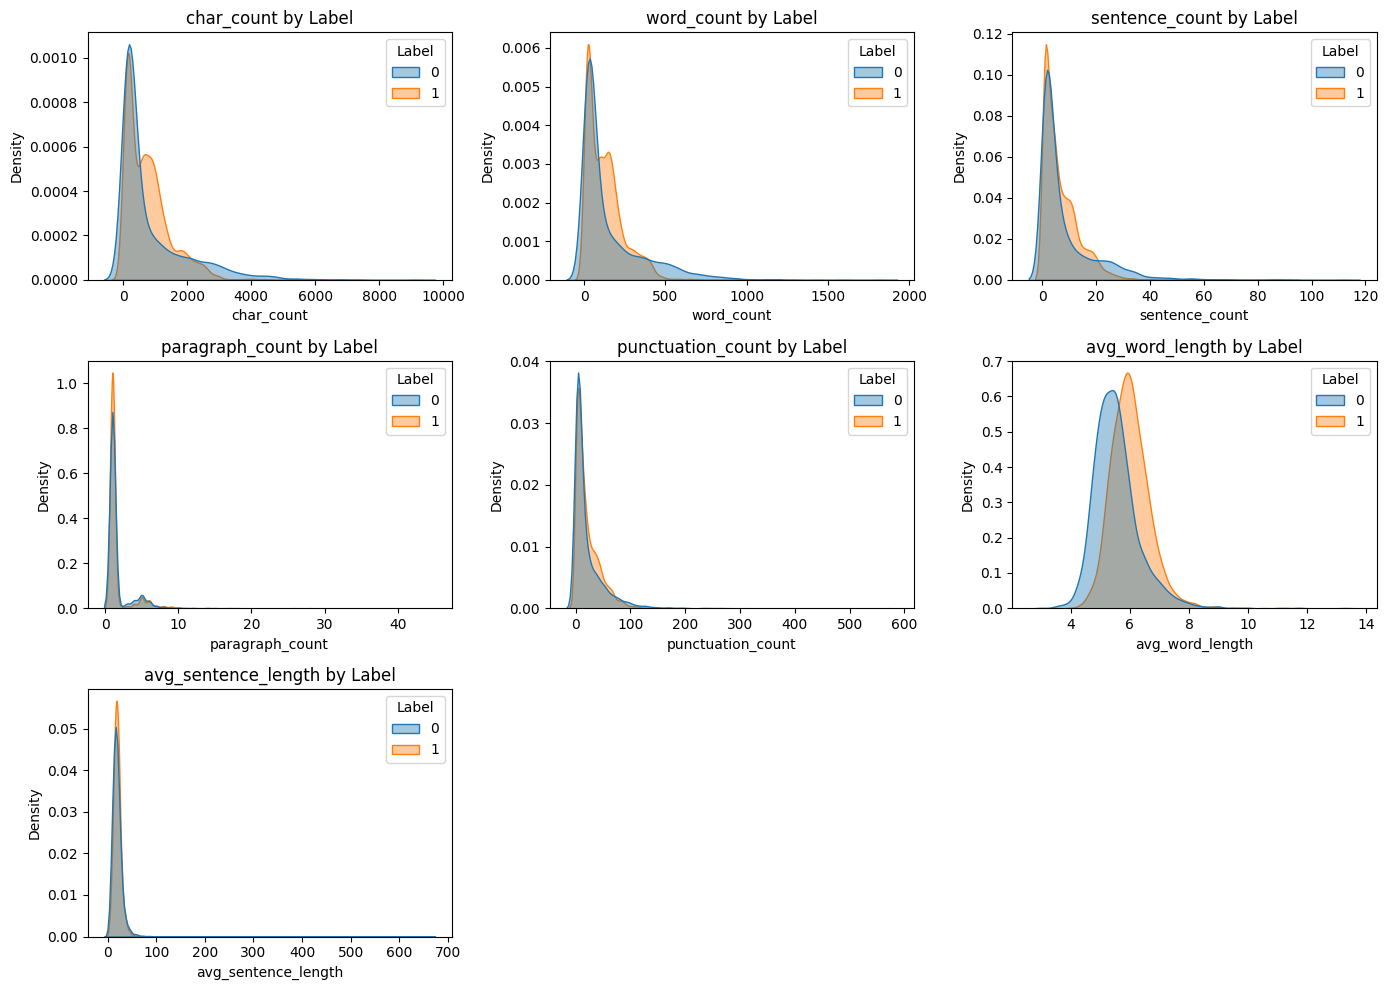

In [5]:
# Visualizing features

import seaborn as sns
import matplotlib.pyplot as plt


basic_features_all = [
    "char_count",
    "word_count",
    "sentence_count",
    "paragraph_count",
    "punctuation_count",
    "avg_word_length",
    "avg_sentence_length"
]

# Plot pairwise on a 3x3 grid
plt.figure(figsize=(14,10))
for i, feat in enumerate(basic_features_all, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()


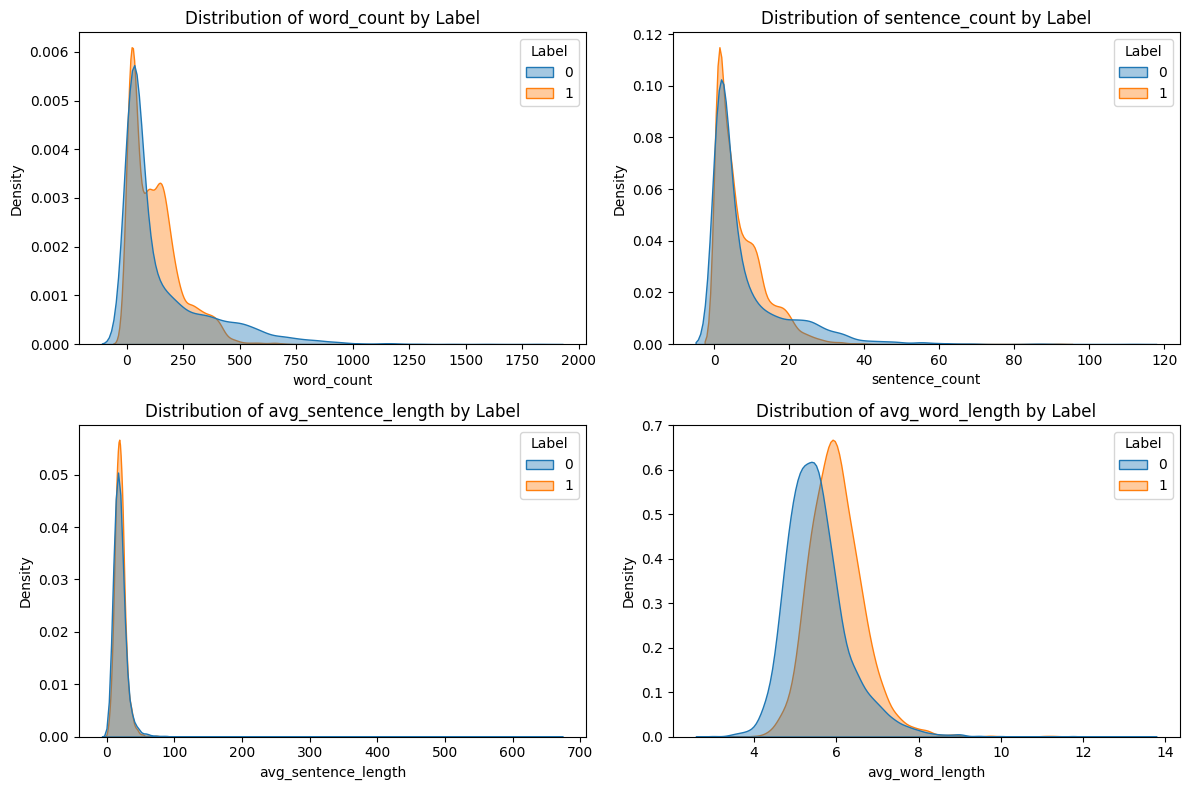

In [ ]:

# Defining features to visualize
features_to_plot = ["word_count", "sentence_count", "avg_sentence_length", "avg_word_length"]

plt.figure(figsize=(12,8))
for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


## Section 2: Lexical Richness & Diversity Features

This section focuses on **word-level and character-level richness** of the text.  
AI-generated texts often have smoother, more uniform language, while 
human writing may show greater variability in vocabulary and style.  

We’ll compute:
- **Unique word counts** and ratios  
- **Stopword ratios** (common function words)  
- **Uppercase, digit, and special character ratios**  
- **Hapax legomena ratio** (words appearing once)  


In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
special_chars = set("~`@#$%^&*()-_=+[]{}|;:'\",<>/?")

print("NLTK stopwords and resources loaded.")


NLTK stopwords and resources loaded.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ajha26\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:

def unique_word_count(text):
    """Count unique words in text."""
    words = text.split()
    return len(set(words))

def hapax_legomena_ratio(text):
    """Ratio of words that appear only once."""
    words = text.split()
    if len(words) == 0:
        return 0
    freq = nltk.FreqDist(words)
    hapax = sum(1 for w in freq if freq[w] == 1)
    return hapax / len(words)

def stopword_count(text):
    """Count stopwords."""
    words = text.lower().split()
    return sum(1 for w in words if w in stop_words)

def special_char_count(text):
    """Count special characters."""
    return sum(1 for ch in text if ch in special_chars)

def uppercase_ratio(text):
    """Proportion of uppercase letters."""
    if len(text) == 0:
        return 0
    return sum(1 for ch in text if ch.isupper()) / len(text)

def digit_ratio(text):
    """Proportion of numeric digits."""
    if len(text) == 0:
        return 0
    return sum(1 for ch in text if ch.isdigit()) / len(text)


In [9]:
# Computing lexical richness features


df["unique_word_count"] = df["Text"].astype(str).apply(unique_word_count)
df["unique_word_ratio"] = df["unique_word_count"] / df["word_count"].replace(0, np.nan)
df["hapax_legomena_ratio"] = df["Text"].astype(str).apply(hapax_legomena_ratio)
df["stopword_count"] = df["Text"].astype(str).apply(stopword_count)
df["stopword_ratio"] = df["stopword_count"] / df["word_count"].replace(0, np.nan)
df["special_char_count"] = df["Text"].astype(str).apply(special_char_count)
df["uppercase_ratio"] = df["Text"].astype(str).apply(uppercase_ratio)
df["digit_ratio"] = df["Text"].astype(str).apply(digit_ratio)

print("Lexical richness features added!")
df.head()


Lexical richness features added!


,Text,Label,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length,unique_word_count,unique_word_ratio,hapax_legomena_ratio,stopword_count,stopword_ratio,special_char_count,uppercase_ratio,digit_ratio
0,6 top keywords used in the meta keywords tags ...,0,82,16,1,1,1,5.125000,16.000000,12,0.750000,0.500000,6,0.375000,0,0.000000,0.012195
1,The officer leading the police investigation i...,0,179,26,1,1,4,6.884615,26.000000,24,0.923077,0.846154,11,0.423077,3,0.011173,0.000000
2,It 's biology vs you . Our ancestors were prog...,0,394,82,7,1,15,4.804878,11.714286,58,0.707317,0.536585,33,0.402439,8,0.017766,0.000000
3,Short version : Lazy programmers . Long versio...,0,320,64,2,1,6,5.000000,32.000000,43,0.671875,0.468750,28,0.437500,4,0.015625,0.000000
4,But after the formation of infertility jumbled...,0,64,10,1,1,2,6.400000,10.000000,10,1.000000,1.000000,6,0.600000,1,0.015625,0.000000


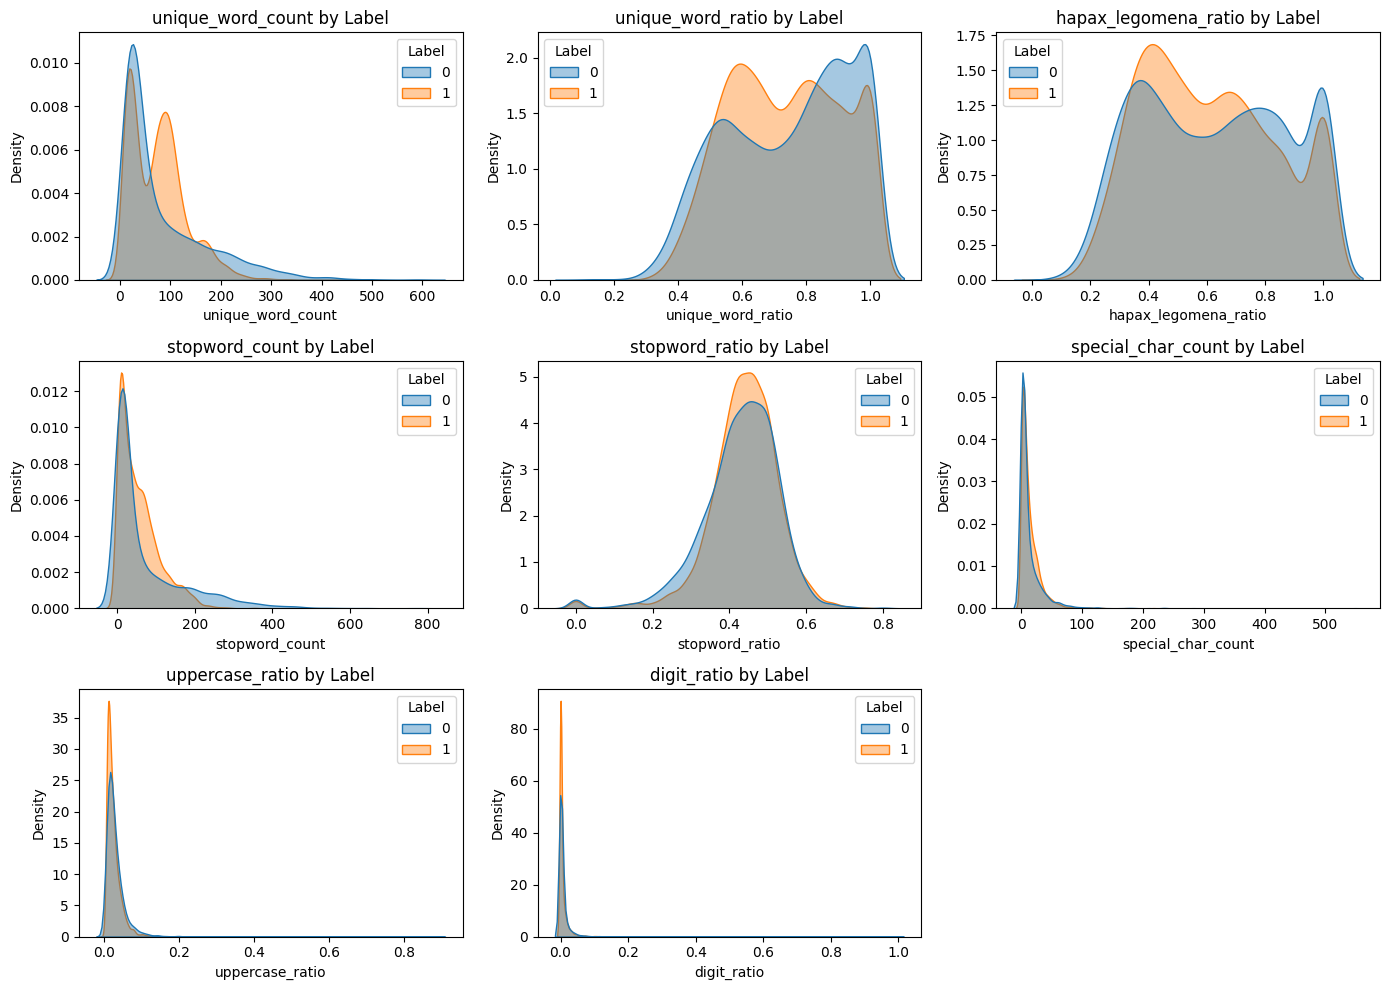

In [10]:
# Visualizng Features

lexical_features_all = [
    "unique_word_count",
    "unique_word_ratio",
    "hapax_legomena_ratio",
    "stopword_count",
    "stopword_ratio",
    "special_char_count",
    "uppercase_ratio",
    "digit_ratio"
]

plt.figure(figsize=(14,10))
for i, feat in enumerate(lexical_features_all, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()


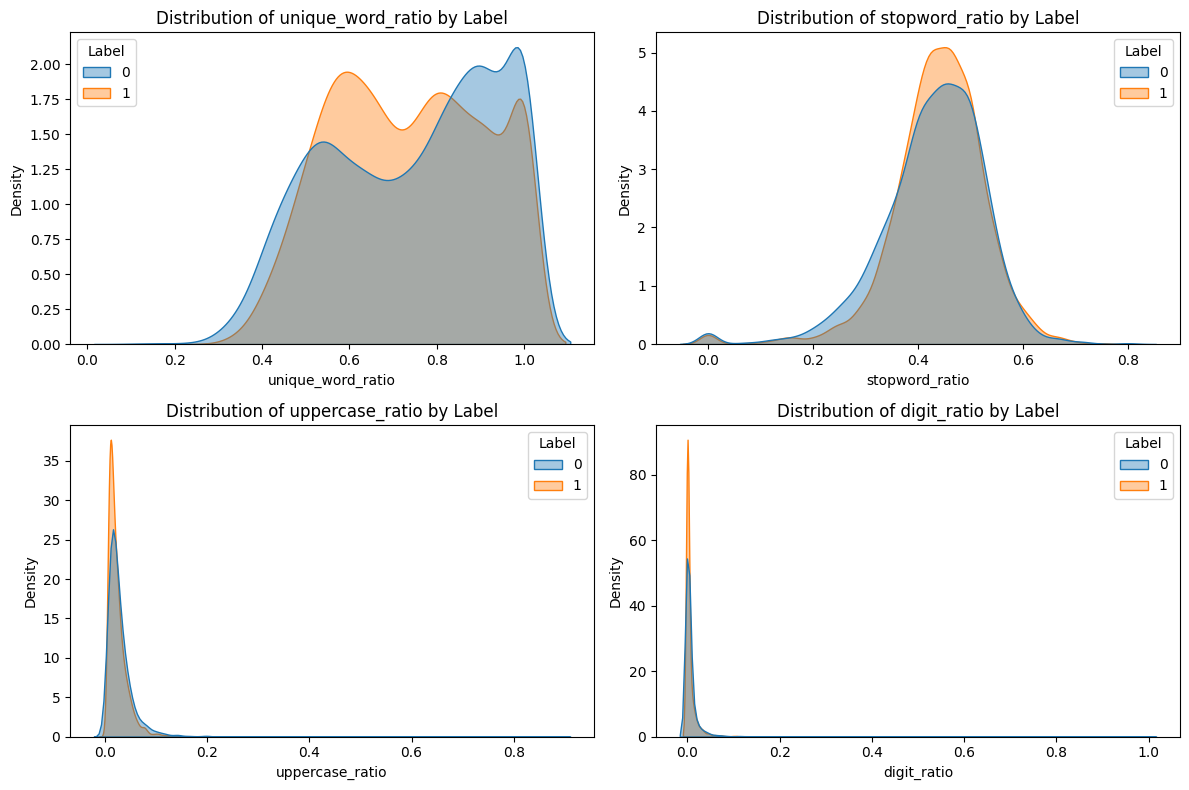

In [11]:

features_to_plot = ["unique_word_ratio", "stopword_ratio", "uppercase_ratio", "digit_ratio"]

plt.figure(figsize=(12,8))
for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


## Section 3: Readability Features

Readability metrics quantify how easy or difficult a text is to read and understand.  
They consider sentence length, word complexity, and syllable patterns.

AI-generated texts often have *consistent readability* (mid-range values),  
while human texts vary more widely depending on writing style and domain.

We’ll compute the following metrics using the **`textstat`** library:

- `flesch_reading_ease` — higher means easier to read (0–100 scale)
- `flesch_kincaid_grade` — U.S. school grade level (higher = more complex)
- `automated_readability_index` — another readability measure based on sentence/word length


In [12]:
# installing textstat
!pip install textstat

import textstat

print("textstat library imported successfully.")


textstat library imported successfully.


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Computing Readability Features
def safe_textstat(func, text):
    """Helper to safely compute readability scores (returns NaN if error)."""
    try:
        return func(text)
    except Exception:
        return np.nan

# Computing readability scores
df["flesch_reading_ease"] = df["Text"].astype(str).apply(lambda x: safe_textstat(textstat.flesch_reading_ease, x))
df["flesch_kincaid_grade"] = df["Text"].astype(str).apply(lambda x: safe_textstat(textstat.flesch_kincaid_grade, x))
df["automated_readability_index"] = df["Text"].astype(str).apply(lambda x: safe_textstat(textstat.automated_readability_index, x))

print("Readability features added!")
df[["flesch_reading_ease", "flesch_kincaid_grade", "automated_readability_index"]].head()


Readability features added!


,flesch_reading_ease,flesch_kincaid_grade,automated_readability_index
0,79.557500,6.137500,6.293125
1,34.021923,14.973077,19.467692
2,77.720000,4.974206,1.691272
3,69.063391,8.429310,7.150260
4,35.945000,10.730000,9.475000


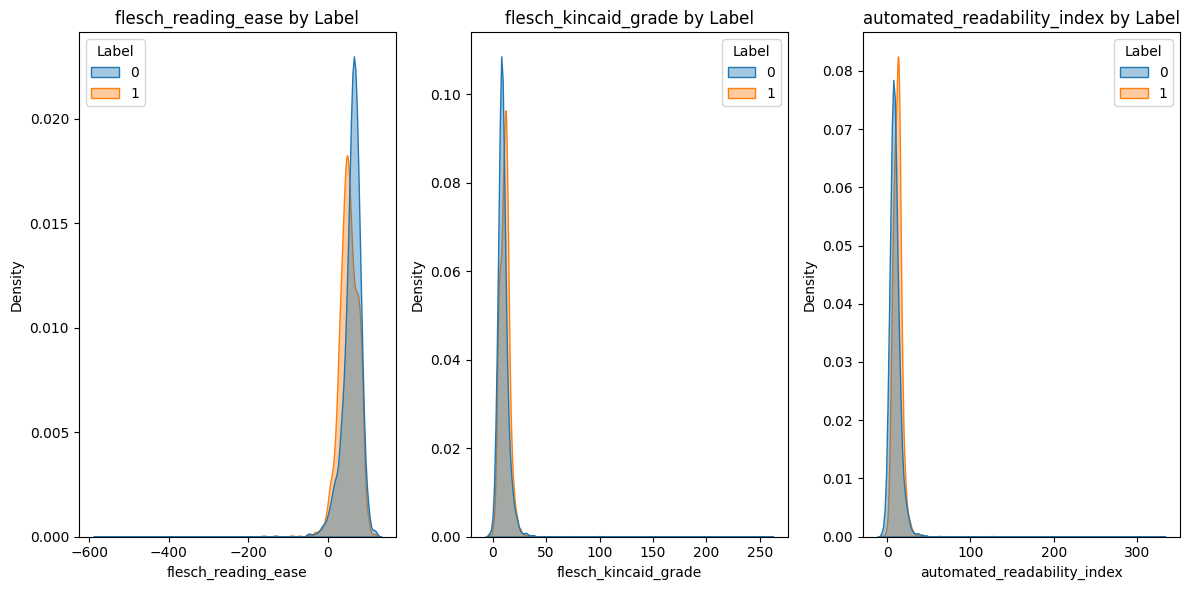

In [14]:
# Visualizing Features:
readability_features = [
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "automated_readability_index"
]

plt.figure(figsize=(12,6))
for i, feat in enumerate(readability_features, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [15]:
# Summary Table:
readability_summary = (
    df.groupby("Label")[readability_features]
    .agg(["mean", "median", "std"])
    .round(2)
)
display(readability_summary)


flesch_reading_ease               flesch_kincaid_grade               \
                     mean median    std                 mean median   std   
Label                                                                       
0                   59.84  63.56  25.28                 9.56   8.79  6.44   
1                   51.54  51.50  23.73                11.04  11.07  4.81   

      automated_readability_index               
                             mean median   std  
Label                                           
0                            9.37   8.51  8.36  
1                           12.28  12.17  5.62

## Section 4: Part-of-Speech (POS) and Syntactic Features

**Part-of-Speech (POS)** tagging identifies the grammatical role of each word:
such as **noun**, **verb**, **adjective**, or **adverb**.  

These syntactic features help capture writing style and structure.  
Human writing often has more personal pronouns and varied syntax,  
while AI-generated text can show smoother and more uniform grammar.

Computing the following features using **SpaCy**:

- `noun_ratio` — proportion of nouns in text  
- `verb_ratio` — proportion of verbs  
- `adj_ratio` — proportion of adjectives  
- `adv_ratio` — proportion of adverbs  
- `personal_pronoun_count` — number of personal pronouns  
- `personal_pronoun_ratio` — relative frequency of personal pronouns  
- `pos_per_sentence_mean` — average number of unique POS tags per sentence


In [ ]:
# !pip install spacy

# Loading small English model (efficient for 10K dataset)
import spacy
nlp = spacy.load("en_core_web_sm")

print("SpaCy model loaded successfully.")


SpaCy model loaded successfully.


In [17]:
# Helper function for POS fetaures calculations

def extract_pos_features(text):
    """Extract POS ratios and pronoun counts from text using SpaCy."""
    doc = nlp(text)
    total_tokens = len([t for t in doc if not t.is_punct and not t.is_space])
    if total_tokens == 0:
        return pd.Series({
            "noun_ratio": 0,
            "verb_ratio": 0,
            "adj_ratio": 0,
            "adv_ratio": 0,
            "personal_pronoun_count": 0,
            "personal_pronoun_ratio": 0,
            "pos_per_sentence_mean": 0
        })
    
    # POS counts
    nouns = sum(1 for t in doc if t.pos_ == "NOUN")
    verbs = sum(1 for t in doc if t.pos_ == "VERB")
    adjs = sum(1 for t in doc if t.pos_ == "ADJ")
    advs = sum(1 for t in doc if t.pos_ == "ADV")
    pronouns = sum(1 for t in doc if t.pos_ == "PRON" and t.lower_ in ["i", "we", "you", "he", "she", "they", "me", "us", "him", "her", "them"])

    # Unique POS tags per sentence
    sentence_pos_counts = []
    for sent in doc.sents:
        pos_tags = set([t.pos_ for t in sent if not t.is_punct])
        sentence_pos_counts.append(len(pos_tags))
    
    pos_per_sentence_mean = np.mean(sentence_pos_counts) if sentence_pos_counts else 0

    return pd.Series({
        "noun_ratio": nouns / total_tokens,
        "verb_ratio": verbs / total_tokens,
        "adj_ratio": adjs / total_tokens,
        "adv_ratio": advs / total_tokens,
        "personal_pronoun_count": pronouns,
        "personal_pronoun_ratio": pronouns / total_tokens,
        "pos_per_sentence_mean": pos_per_sentence_mean
    })


In [18]:
# Applying POS Extraction

from tqdm import tqdm     
tqdm.pandas()             


try:
    pos_features = df["Text"].astype(str).progress_apply(extract_pos_features)
except Exception as e:
    print(" tqdm progress bar failed — running without it.")
    print("Error details:", e)
    
    # fallback: simple apply + periodic status prints
    pos_features_list = []
    total_rows = len(df)
    for i, text in enumerate(df["Text"].astype(str)):
        if i % 1000 == 0:
            print(f"Processing row {i}/{total_rows}...")
        pos_features_list.append(extract_pos_features(text))
    pos_features = pd.DataFrame(pos_features_list)

# Merging new features into main DataFrame
df = pd.concat([df, pos_features], axis=1)

print(" POS and syntactic features successfully added!")
df[[
    "noun_ratio",
    "verb_ratio",
    "adj_ratio",
    "adv_ratio",
    "personal_pronoun_ratio",
    "pos_per_sentence_mean"
]].head()


100%|██████████| 10000/10000 [03:59<00:00, 41.78it/s]

 POS and syntactic features successfully added!


,noun_ratio,verb_ratio,adj_ratio,adv_ratio,personal_pronoun_ratio,pos_per_sentence_mean
0,0.250000,0.187500,0.125000,0.000000,0.000000,8.000000
1,0.269231,0.153846,0.038462,0.076923,0.038462,10.000000
2,0.166667,0.152778,0.097222,0.055556,0.083333,6.428571
3,0.206897,0.103448,0.155172,0.017241,0.017241,6.666667
4,0.300000,0.100000,0.000000,0.100000,0.000000,7.000000


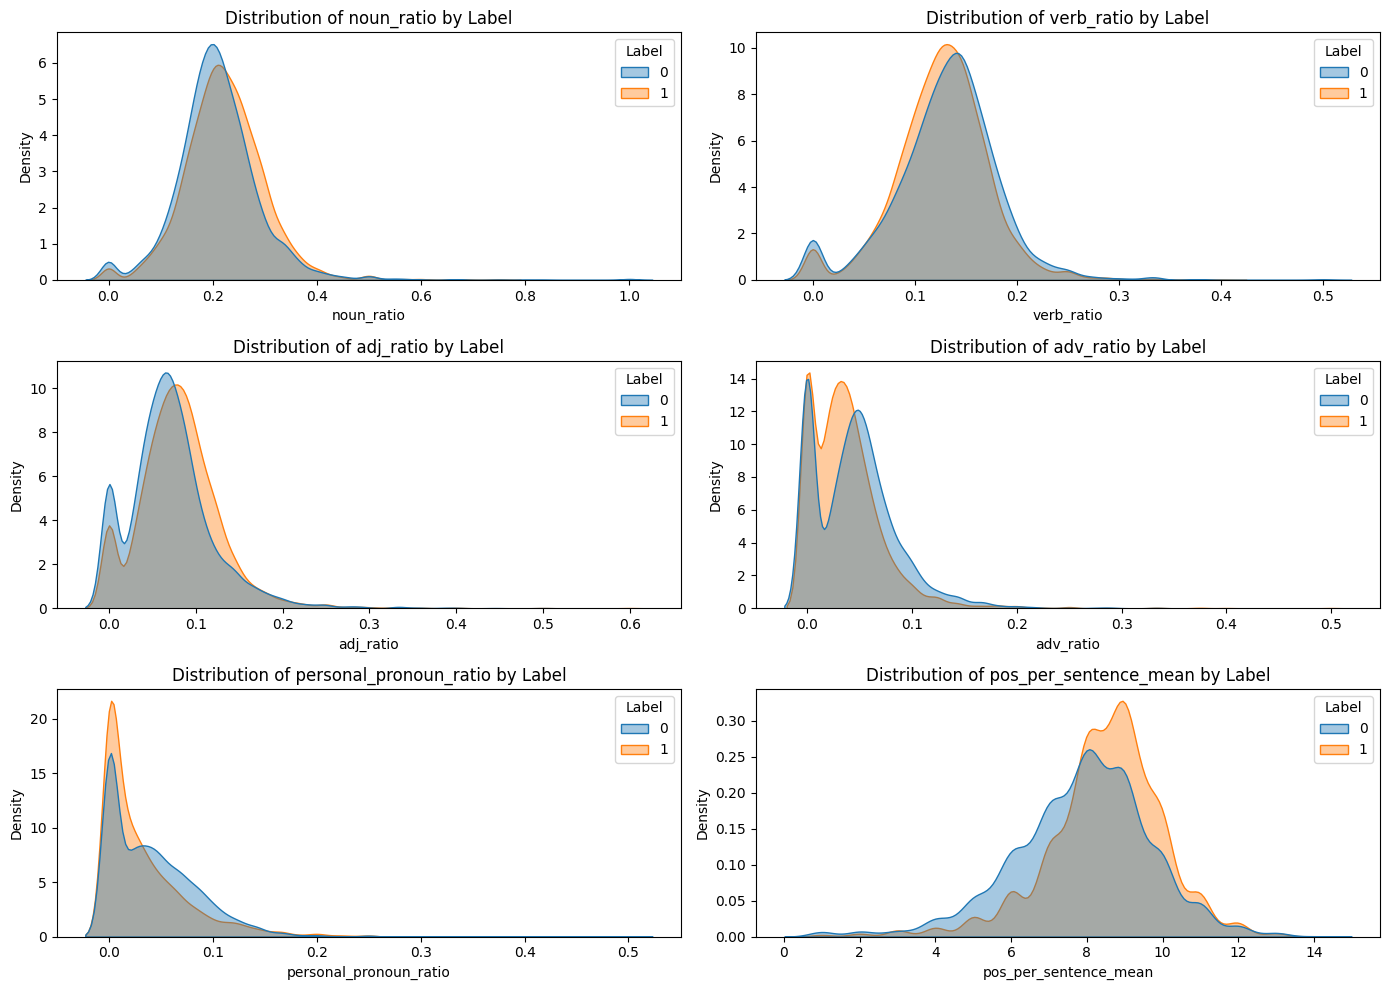

In [19]:
# Visualizing Feataures
pos_features_to_plot = [
    "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
    "personal_pronoun_ratio", "pos_per_sentence_mean"
]

plt.figure(figsize=(14,10))
for i, feat in enumerate(pos_features_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [20]:
# Summary Table

pos_summary = (
    df.groupby("Label")[pos_features_to_plot]
    .agg(["mean", "median", "std"])
    .round(3)
)
display(pos_summary)


noun_ratio               verb_ratio               adj_ratio         \
            mean median    std       mean median    std      mean median   
Label                                                                      
0          0.209  0.204  0.082      0.131  0.134  0.051     0.071  0.067   
1          0.223  0.219  0.077      0.126  0.128  0.046     0.081  0.078   

             adv_ratio               personal_pronoun_ratio                \
         std      mean median    std                   mean median    std   
Label                                                                       
0      0.050     0.046  0.044  0.040                  0.041  0.033  0.043   
1      0.048     0.037  0.032  0.035                  0.033  0.018  0.042   

      pos_per_sentence_mean                
                       mean median    std  
Label                                      
0                     7.872  8.000  1.815  
1                     8.477  8.617  1.555

In [21]:
pip install ipywidgets --upgrade


Note: you may need to restart the kernel to use updated packages.


## Section 5: Sentiment and Subjectivity Features

This section measures the **emotional polarity** and **subjectivity** of each text.  
These cues can help differentiate human and AI writing, since:

- **Humans** often express opinions and emotions → higher subjectivity and polarity range.  
- **AI-generated text** tends to stay neutral and balanced → lower sentiment variance.

Computing:

- `sentiment_polarity` — overall positivity/negativity ∈ [–1, +1]  
- `sentiment_subjectivity` — degree of personal opinion ∈ [0, 1]  

Using the lightweight **TextBlob** library for quick sentiment extraction.


In [22]:
!pip install textblob

from textblob import TextBlob

print("TextBlob library imported successfully.")


TextBlob library imported successfully.


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Computing sentiment polarity and subjectivity


def get_sentiment(text):
    """Return polarity and subjectivity scores using TextBlob."""
    blob = TextBlob(text)
    return pd.Series({
        "sentiment_polarity": blob.sentiment.polarity,
        "sentiment_subjectivity": blob.sentiment.subjectivity
    })

from tqdm import tqdm
tqdm.pandas()

try:
    sentiment_features = df["Text"].astype(str).progress_apply(get_sentiment)
except Exception as e:
    print("tqdm progress bar failed — running without it.")
    print("Error details:", e)
    sentiment_features = df["Text"].astype(str).apply(get_sentiment)

# Merging with main DataFrame
df = pd.concat([df, sentiment_features], axis=1)

print("Sentiment and subjectivity features added!")
df[["sentiment_polarity", "sentiment_subjectivity"]].head()


100%|██████████| 10000/10000 [00:08<00:00, 1166.71it/s]

Sentiment and subjectivity features added!


,sentiment_polarity,sentiment_subjectivity
0,0.500000,0.500000
1,0.062500,0.666667
2,-0.072222,0.562698
3,0.022222,0.477778
4,0.000000,0.000000


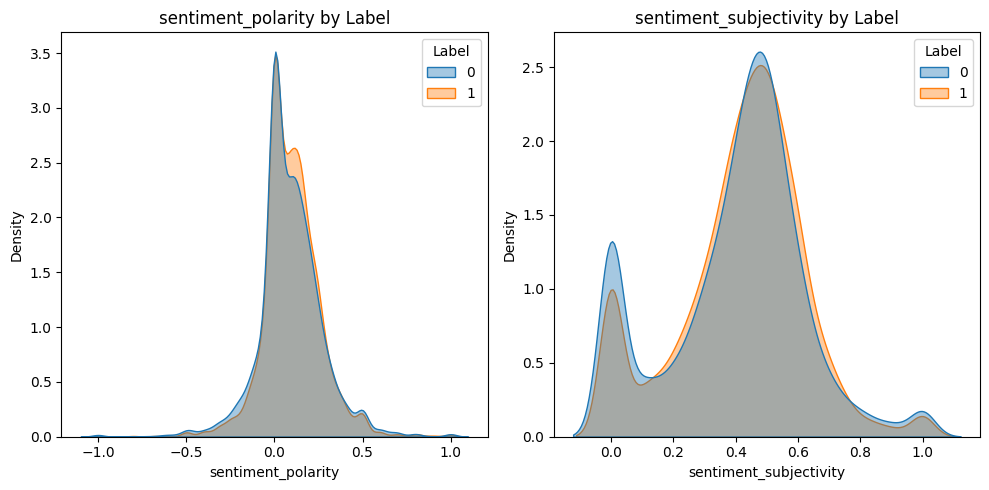

In [24]:
# Plotting sentiment and subjectivity distributions

sentiment_features = ["sentiment_polarity", "sentiment_subjectivity"]

plt.figure(figsize=(10,5))
for i, feat in enumerate(sentiment_features, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [25]:
# Summary Table:

sentiment_summary = (
    df.groupby("Label")[sentiment_features]
      .agg(["mean", "median", "std"])
      .round(3)
)
display(sentiment_summary)


sentiment_polarity               sentiment_subjectivity              
                    mean median    std                   mean median    std
Label                                                                      
0                  0.088  0.075  0.181                  0.402  0.442  0.223
1                  0.096  0.084  0.162                  0.418  0.447  0.205

## Section 6: Perplexity & Fluency Features

**Perplexity** measures how well a language model can predict a text.  
- Lower perplexity → the text is more predictable and fluent (often AI-like).  
- Higher perplexity → the text is more surprising or varied (often human-like).

We'll use the **GPT-2** model from Hugging Face to estimate:
- `ppl_mean` — average perplexity across text chunks  
- `ppl_max` — maximum perplexity (captures variability)

To keep it efficient, computing perplexity on smaller chunks (e.g., 200 tokens max)  
and skipping very long texts to prevent CPU overload.


In [26]:
#  Installing and importing Hugging Face libraries
import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from tqdm import tqdm

# Loading pretrained GPT-2 model and tokenizer
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()  # inference mode
print("GPT-2 model and tokenizer loaded successfully.")


GPT-2 model and tokenizer loaded successfully.


In [27]:
#!pip install hf_xet

In [28]:
# function to calculate perplexity

def compute_perplexity(text, max_length=200):
    """
    Compute perplexity of text using GPT-2.
    Texts are truncated to `max_length` tokens for efficiency.
    """
    try:
        encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
        with torch.no_grad():
            outputs = model(**encodings, labels=encodings["input_ids"])
        loss = outputs.loss.item()
        ppl = torch.exp(torch.tensor(loss)).item()
        return ppl
    except Exception:
        return None


In [29]:
# Computing mean and max perplexity per text


def compute_text_ppl_stats(text):
    """
    Compute mean and max perplexity across text chunks.
    Breaks long text into sentences or chunks of ~100 words.
    """
    sents = text.split(". ")
    sents = [s for s in sents if len(s.split()) > 3]
    if not sents:
        return pd.Series({"ppl_mean": np.nan, "ppl_max": np.nan})
    
    ppl_values = []
    for sent in sents[:5]:  # limit to first 5 chunks for speed
        ppl = compute_perplexity(sent)
        if ppl:
            ppl_values.append(ppl)
    
    if not ppl_values:
        return pd.Series({"ppl_mean": np.nan, "ppl_max": np.nan})
    
    return pd.Series({
        "ppl_mean": np.mean(ppl_values),
        "ppl_max": np.max(ppl_values)
    })


tqdm.pandas()
df[["ppl_mean", "ppl_max"]] = df["Text"].astype(str).progress_apply(compute_text_ppl_stats)

print("Perplexity features added!")
df[["ppl_mean", "ppl_max"]].head()


100%|██████████| 10000/10000 [09:45<00:00, 17.08it/s]

Perplexity features added!


,ppl_mean,ppl_max
0,108.407303,108.407303
1,36.297779,36.297779
2,534.182751,1752.759888
3,521.213543,1412.020752
4,573.732788,573.732788


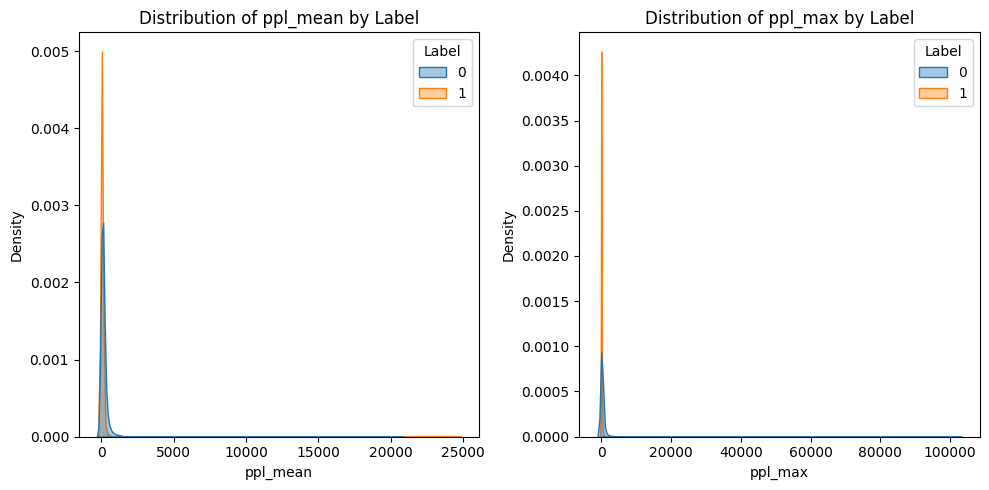

In [30]:
# Plotting Perplexity Distributions


import seaborn as sns
import matplotlib.pyplot as plt

perplexity_features = ["ppl_mean", "ppl_max"]

plt.figure(figsize=(10, 5))
for i, feat in enumerate(perplexity_features, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [31]:
# Summary Table

perplexity_summary = (
    df.groupby("Label")[perplexity_features]
    .agg(["mean", "median", "std"])
    .round(3)
)
display(perplexity_summary)


ppl_mean                  ppl_max                   
          mean  median     std     mean   median       std
Label                                                     
0      187.733  98.685  530.31  378.107  141.239  1837.688
1       66.627  38.301  389.12   98.634   53.982   403.860

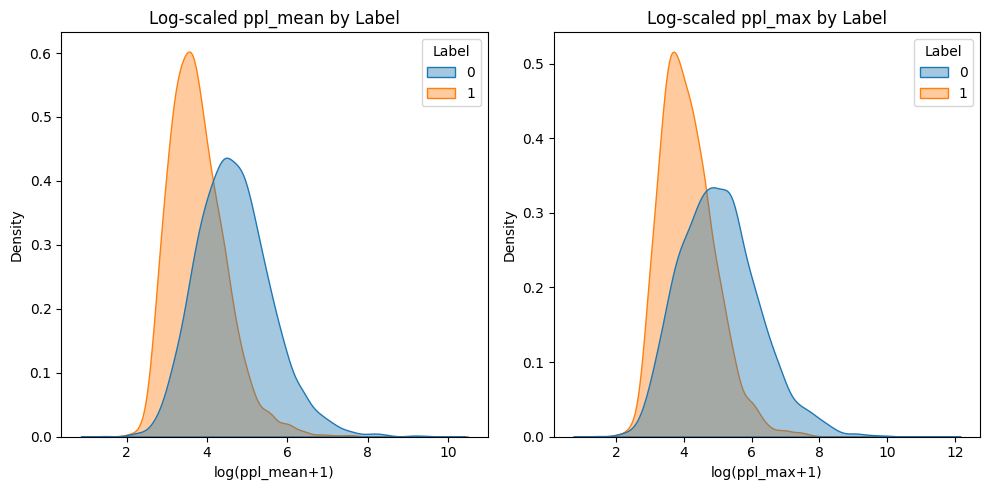

In [32]:
# log scale visualization of perplexity 

plt.figure(figsize=(10, 5))
for i, feat in enumerate(perplexity_features, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=np.log1p(df[feat]), hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Log-scaled {feat} by Label")
    plt.xlabel(f"log({feat}+1)")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


## Section 7: Discourse / Structural Features

This section captures higher-level organization and coherence cues in writing.

We'll compute:
- `discourse_marker_count` — number of transition or connective words (e.g., "however", "therefore", "moreover")
- `title_repetition_count` — absolute count of repetitions of the first sentence/title throughout the text
- `title_repetition_ratio` — normalized by total word count


In [33]:
# Common discourse markers used in academic and formal text
discourse_markers = [
    "however", "therefore", "moreover", "furthermore", "nevertheless", "nonetheless",
    "consequently", "thus", "hence", "accordingly", "meanwhile", "instead",
    "nonetheless", "nonetheless", "similarly", "alternatively", "additionally",
    "in contrast", "in conclusion", "for example", "for instance", "on the other hand",
    "as a result", "overall", "finally", "in summary", "nonetheless"
]

discourse_markers = set([m.lower() for m in discourse_markers])
print(f"Loaded {len(discourse_markers)} discourse markers.")


Loaded 24 discourse markers.


In [34]:
# functions for feature extraction

import re

def count_discourse_markers(text):
    """Count occurrences of predefined discourse markers."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0
    words = re.findall(r"\b\w+\b", text.lower())
    return sum(1 for w in words if w in discourse_markers)


def count_title_repetitions(text):
    """Count how often the first sentence (title-like) repeats in the text."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series({"title_repetition_count": 0, "title_repetition_ratio": 0})
    
    # Extracting first sentence (assumed as title)
    sentences = re.split(r"[.!?]\s+", text.strip())
    if len(sentences) == 0:
        return pd.Series({"title_repetition_count": 0, "title_repetition_ratio": 0})
    
    title = sentences[0].strip().lower()
    if len(title.split()) < 3:  # too short to count as title
        return pd.Series({"title_repetition_count": 0, "title_repetition_ratio": 0})
    
    # Counting how many times this title reappears (excluding the first instance)
    title_pattern = re.escape(title)
    repetitions = len(re.findall(title_pattern, text.lower())) - 1
    
    total_words = len(text.split())
    ratio = repetitions / total_words if total_words > 0 else 0
    
    return pd.Series({
        "title_repetition_count": repetitions,
        "title_repetition_ratio": ratio
    })


In [35]:
# Applying discourse and repetition features

from tqdm import tqdm
tqdm.pandas()

# Computing discourse marker counts
df["discourse_marker_count"] = df["Text"].astype(str).progress_apply(count_discourse_markers)

# Computing title repetition counts and ratios
title_reps = df["Text"].astype(str).progress_apply(count_title_repetitions)

# Merging results into main dataframe
df = pd.concat([df, title_reps], axis=1)

print(" Discourse and structural features added successfully!")
df[["discourse_marker_count", "title_repetition_count", "title_repetition_ratio"]].head()


100%|██████████| 10000/10000 [00:02<00:00, 3781.55it/s]

 Discourse and structural features added successfully!


,discourse_marker_count,title_repetition_count,title_repetition_ratio
0,0,0.0,0.0
1,0,0.0,0.0
2,0,0.0,0.0
3,0,0.0,0.0
4,0,0.0,0.0


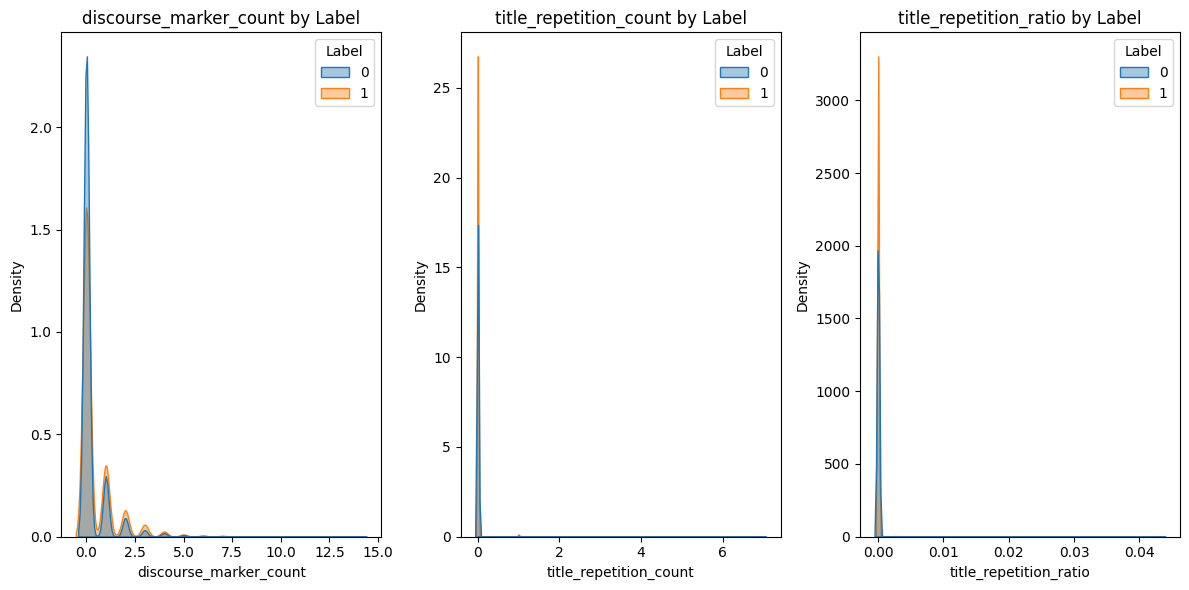

In [36]:
# Plotting feature distributions


discourse_features = [
    "discourse_marker_count",
    "title_repetition_count",
    "title_repetition_ratio"
]

plt.figure(figsize=(12,6))
for i, feat in enumerate(discourse_features, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


In [37]:
# Summary statistics by label

discourse_summary = (
    df.groupby("Label")[discourse_features]
    .agg(["mean", "median", "std"])
    .round(3)
)
display(discourse_summary)


discourse_marker_count               title_repetition_count         \
                        mean median    std                   mean median   
Label                                                                      
0                      0.260    0.0  0.772                  0.005    0.0   
1                      0.465    0.0  0.995                  0.005    0.0   

             title_repetition_ratio                
         std                   mean median    std  
Label                                              
0      0.115                    0.0    0.0  0.001  
1      0.080                    0.0    0.0  0.001

## Section 8: 
#### Word Entropy & Character Entropy
#### Adjacent Sentence Coherence Score (SBERT)

In [38]:
# Word & Character Entropy Features

import numpy as np
from collections import Counter
import math

def compute_entropy(items):
    """General entropy calculator for any list of items."""
    if len(items) == 0:
        return 0
    counts = Counter(items)
    total = sum(counts.values())
    probs = np.array([c/total for c in counts.values()])
    return -(probs * np.log2(probs)).sum()

def word_entropy(text):
    words = text.split()
    return compute_entropy(words)

def char_entropy(text):
    chars = list(text)
    return compute_entropy(chars)

df["word_entropy"] = df["Text"].astype(str).apply(word_entropy)
df["char_entropy"] = df["Text"].astype(str).apply(char_entropy)

print("Word & character entropy features added!")
df[["word_entropy", "char_entropy"]].head()


Word & character entropy features added!


,word_entropy,char_entropy
0,3.500000,3.931515
1,4.546594,4.256504
2,5.626867,4.308066
3,5.188810,4.146873
4,3.321928,4.114558


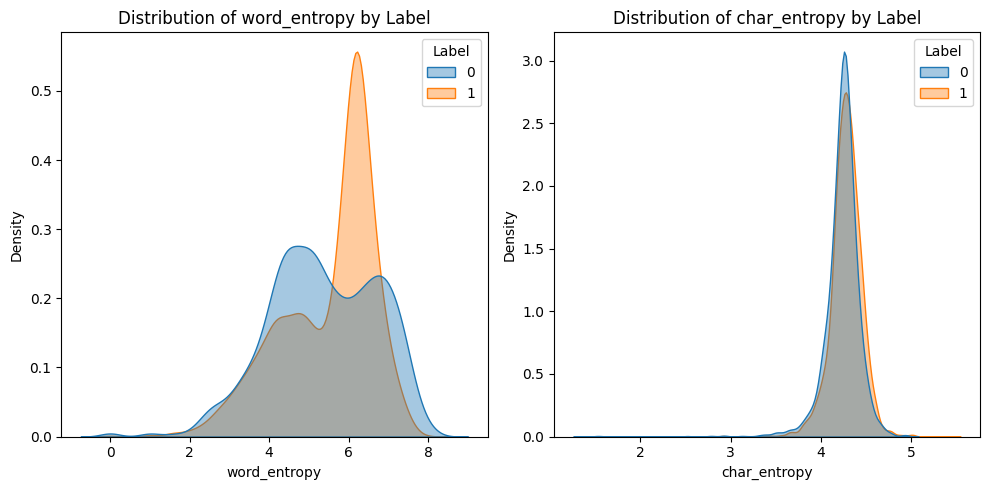

word_entropy               char_entropy              
              mean median    std         mean median    std
Label                                                      
0            5.347  5.296  1.362        4.232  4.252  0.209
1            5.496  5.934  1.186        4.277  4.281  0.177

In [39]:
# Visualization — Entropy Features

entropy_features = ["word_entropy", "char_entropy"]

plt.figure(figsize=(10,5))
for i, feat in enumerate(entropy_features, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Summary Table
entropy_summary = (
    df.groupby("Label")[entropy_features]
      .agg(["mean", "median", "std"])
      .round(3)
)
display(entropy_summary)


In [40]:
# Adjacent Sentence Coherence (SBERT Similarity)

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

# Loading lightweight SBERT model
sbert = SentenceTransformer("all-MiniLM-L6-v2")
print("SBERT model loaded successfully.")

def split_sentences(text):
    """Simple sentence splitter."""
    sentences = re.split(r"[.!?]+\s+", text.strip())
    sentences = [s for s in sentences if len(s.split()) > 3]
    return sentences

def coherence_features(text):
    """
    Compute cosine similarity between adjacent sentence embeddings.
    Returns avg and std of similarities.
    """
    sentences = split_sentences(text)
    if len(sentences) < 2:
        return pd.Series({
            "avg_sentence_similarity": np.nan,
            "std_sentence_similarity": np.nan
        })
    
    # Encoding sentences
    embeddings = sbert.encode(sentences)
    
    # Computing adjacent cosine similarities
    sims = []
    for i in range(len(embeddings) - 1):
        sim = cosine_similarity(
            embeddings[i].reshape(1, -1),
            embeddings[i+1].reshape(1, -1)
        )[0][0]
        sims.append(sim)
    
    return pd.Series({
        "avg_sentence_similarity": np.mean(sims),
        "std_sentence_similarity": np.std(sims)
    })


from tqdm import tqdm
tqdm.pandas()

df[["avg_sentence_similarity", "std_sentence_similarity"]] = (
    df["Text"].astype(str).progress_apply(coherence_features)
)

print("Coherence features added!")
df[["avg_sentence_similarity", "std_sentence_similarity"]].head()


SBERT model loaded successfully.


100%|██████████| 10000/10000 [02:30<00:00, 66.34it/s]

Coherence features added!


,avg_sentence_similarity,std_sentence_similarity
0,NaN,NaN
1,NaN,NaN
2,0.320988,0.142229
3,0.305164,0.168947
4,NaN,NaN


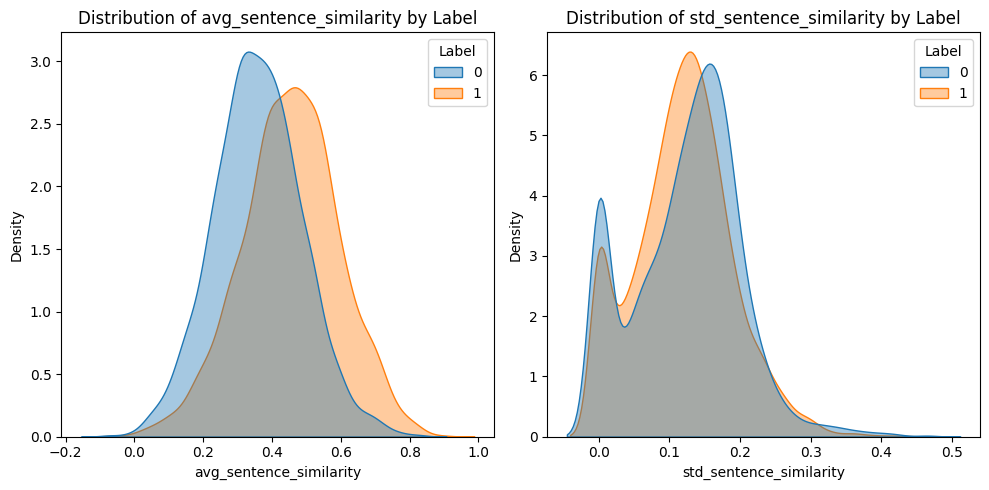

avg_sentence_similarity               std_sentence_similarity         \
                         mean median    std                    mean median   
Label                                                                        
0                       0.358  0.357  0.128                   0.124  0.134   
1                       0.453  0.456  0.142                   0.119  0.121   

              
         std  
Label         
0      0.076  
1      0.069

In [41]:
# Visualization — Coherence Features

coherence_features = ["avg_sentence_similarity", "std_sentence_similarity"]

plt.figure(figsize=(10,5))
for i, feat in enumerate(coherence_features, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(data=df, x=feat, hue="Label", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribution of {feat} by Label")
    plt.xlabel(feat)
    plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Summary Table
coherence_summary = (
    df.groupby("Label")[coherence_features]
      .agg(["mean", "median", "std"])
      .round(3)
)
display(coherence_summary)


## Section 9: Saving and Summarizing the Final Feature Dataset

Now that all linguistic, stylistic, and structural features have been created,  
we’ll finalize this dataset by:

1. Performing last-minute sanity checks  
2. Summarizing feature categories and counts  
3. Saving the clean, feature-enriched dataset for modeling  


In [ ]:

import numpy as np

print(f"Final dataset shape before cleaning: {df.shape}")

# Checking missing values
missing_summary = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column (top 15):")
display(missing_summary.head(15))

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Filling missing numeric columns with column means
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print(f"\n Missing and infinite values handled. Final shape: {df.shape}")


Final dataset shape before cleaning: (10000, 38)

Missing values per column (top 15):


std_sentence_similarity    3042
avg_sentence_similarity    3042
ppl_mean                     58
ppl_max                      58
Text                          0
Label                         0
paragraph_count               0
sentence_count                0
word_count                    0
char_count                    0
punctuation_count             0
avg_word_length               0
avg_sentence_length           0
unique_word_count             0
special_char_count            0
dtype: int64


 Missing and infinite values handled. Final shape: (10000, 38)


In [43]:
#  Summary of all feature categories

feature_groups = {
    "Basic Text Structure": [
        "char_count", "word_count", "sentence_count", "paragraph_count",
        "punctuation_count", "avg_word_length", "avg_sentence_length"
    ],
    "Lexical Richness & Diversity": [
        "unique_word_count", "unique_word_ratio", "hapax_legomena_ratio",
        "stopword_count", "stopword_ratio", "special_char_count",
        "uppercase_ratio", "digit_ratio"
    ],
    "Readability": [
        "flesch_reading_ease", "flesch_kincaid_grade", "automated_readability_index"
    ],
    "POS & Syntax": [
        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
        "personal_pronoun_count", "personal_pronoun_ratio", "pos_per_sentence_mean"
    ],
    "Sentiment": [
        "sentiment_polarity", "sentiment_subjectivity"
    ],
    "Perplexity": [
        "ppl_mean", "ppl_max"
    ],
    "Discourse & Structure": [
        "discourse_marker_count", "title_repetition_count", "title_repetition_ratio"
    ],
    "Entropy": [
        "word_entropy", "char_entropy"
    ],
    "Coherence": [
        "avg_sentence_similarity", "std_sentence_similarity"
    ]
}

summary_table = pd.DataFrame({
    "Feature Group": list(feature_groups.keys()),
    "Number of Features": [len(v) for v in feature_groups.values()],
    "Feature Names": [", ".join(v) for v in feature_groups.values()]
})

display(summary_table)

total_features = sum(len(v) for v in feature_groups.values())
print(f"\nTotal Engineered Features: {total_features}")


,Feature Group,Number of Features,Feature Names
0,Basic Text Structure,7,"char_count, word_count, sentence_count, paragr..."
1,Lexical Richness & Diversity,8,"unique_word_count, unique_word_ratio, hapax_le..."
2,Readability,3,"flesch_reading_ease, flesch_kincaid_grade, aut..."
3,POS & Syntax,7,"noun_ratio, verb_ratio, adj_ratio, adv_ratio, ..."
4,Sentiment,2,"sentiment_polarity, sentiment_subjectivity"
5,Perplexity,2,"ppl_mean, ppl_max"
6,Discourse & Structure,3,"discourse_marker_count, title_repetition_count..."
7,Entropy,2,"word_entropy, char_entropy"
8,Coherence,2,"avg_sentence_similarity, std_sentence_similarity"



Total Engineered Features: 36


In [44]:
# Saving the final features dataset 

import os

save_dir = r"C:\Users\ajha26\Desktop\IS\Data"
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, "IS_Dataset_AI_vs_Human_Features.csv")
xlsx_path = os.path.join(save_dir, "IS_Dataset_AI_vs_Human_Features.xlsx")

df.to_csv(csv_path, index=False)
df.to_excel(xlsx_path, index=False)

print("Feature-enriched dataset saved successfully!")
print(f" CSV file saved to: {csv_path}")
print(f" Excel file saved to: {xlsx_path}")


Feature-enriched dataset saved successfully!
 CSV file saved to: C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Features.csv
 Excel file saved to: C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_Features.xlsx


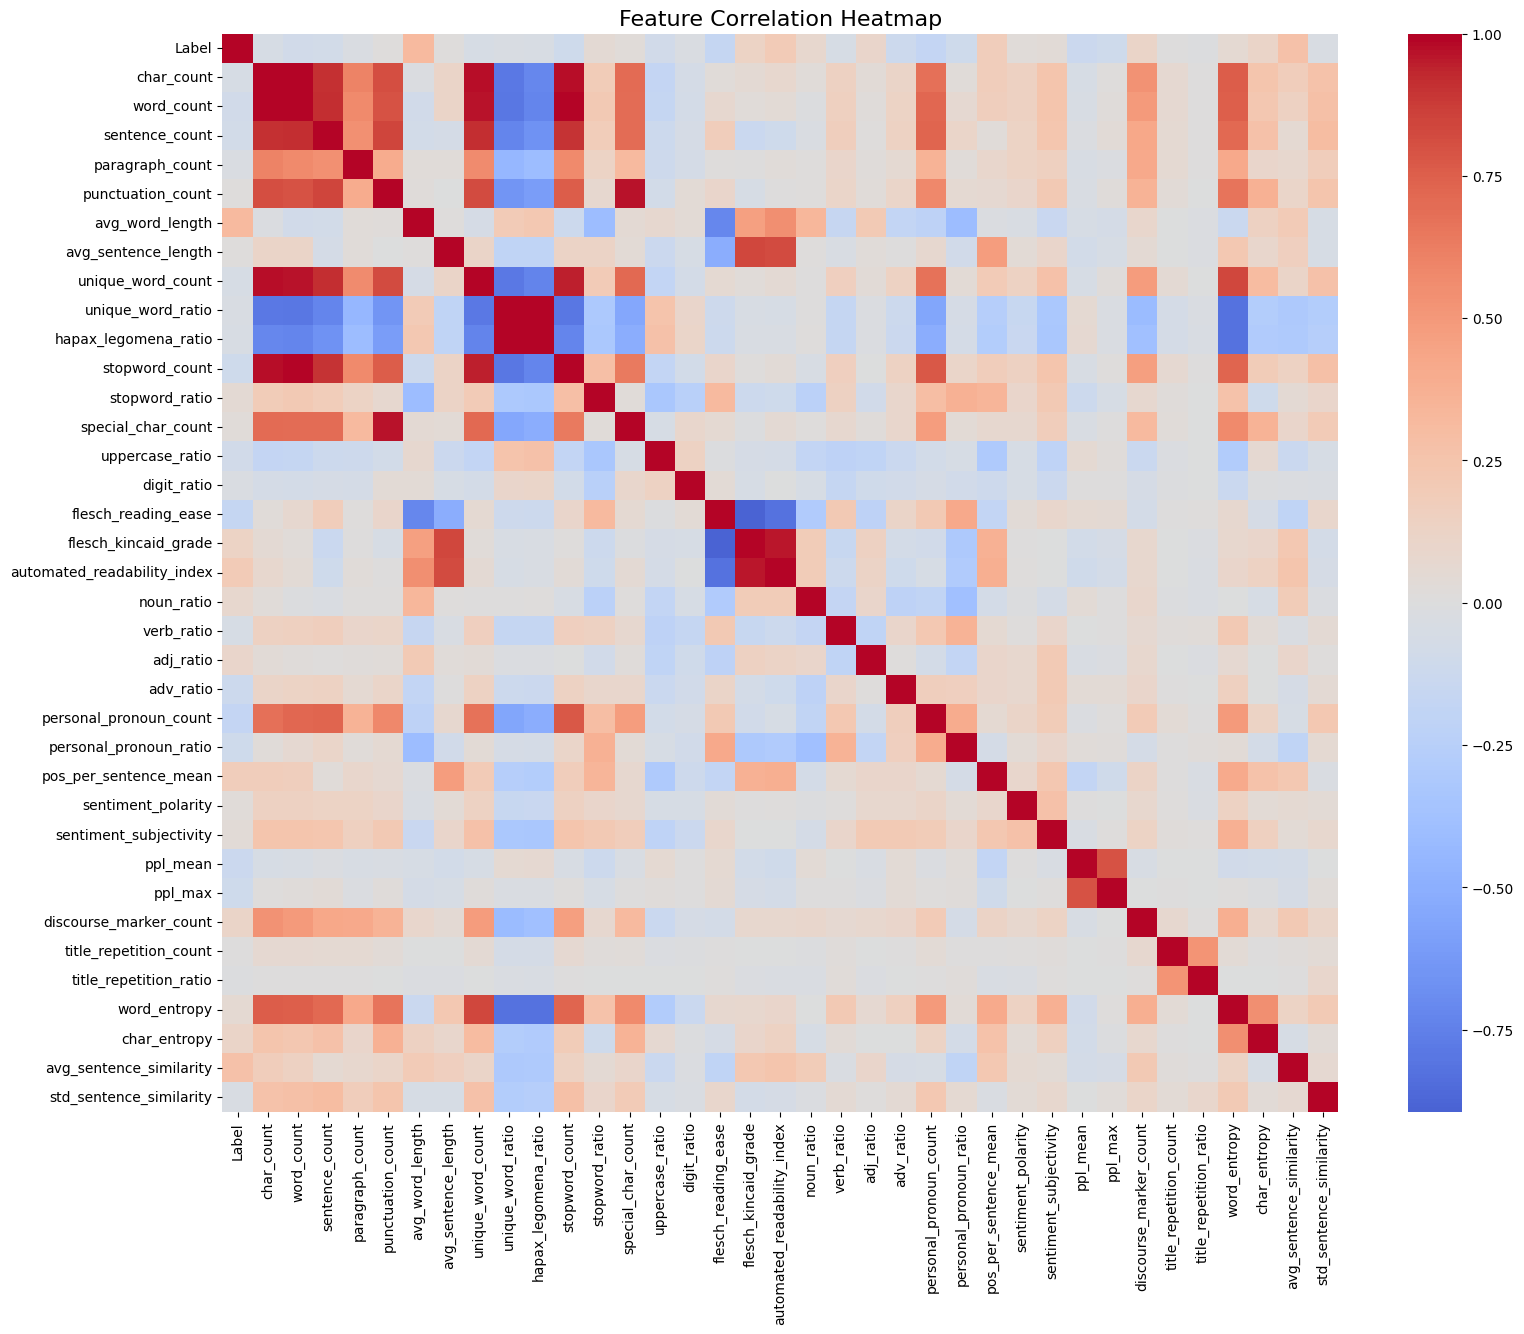

In [45]:
# Correlation heatmap for numeric features

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar=True)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()


In [46]:
# Final dataset preview

print("Final feature-enhanced dataset ready for modeling!")
print(f"Shape: {df.shape}")
display(df.head())


Final feature-enhanced dataset ready for modeling!
Shape: (10000, 38)


,Text,Label,char_count,word_count,sentence_count,paragraph_count,punctuation_count,avg_word_length,avg_sentence_length,unique_word_count,...,sentiment_subjectivity,ppl_mean,ppl_max,discourse_marker_count,title_repetition_count,title_repetition_ratio,word_entropy,char_entropy,avg_sentence_similarity,std_sentence_similarity
0,6 top keywords used in the meta keywords tags ...,0,82,16,1,1,1,5.125000,16.000000,12,...,0.500000,108.407303,108.407303,0,0.0,0.0,3.500000,3.931515,0.407276,0.121442
1,The officer leading the police investigation i...,0,179,26,1,1,4,6.884615,26.000000,24,...,0.666667,36.297779,36.297779,0,0.0,0.0,4.546594,4.256504,0.407276,0.121442
2,It 's biology vs you . Our ancestors were prog...,0,394,82,7,1,15,4.804878,11.714286,58,...,0.562698,534.182751,1752.759888,0,0.0,0.0,5.626867,4.308066,0.320988,0.142229
3,Short version : Lazy programmers . Long versio...,0,320,64,2,1,6,5.000000,32.000000,43,...,0.477778,521.213543,1412.020752,0,0.0,0.0,5.188810,4.146873,0.305164,0.168947
4,But after the formation of infertility jumbled...,0,64,10,1,1,2,6.400000,10.000000,10,...,0.000000,573.732788,573.732788,0,0.0,0.0,3.321928,4.114558,0.407276,0.121442
